## 导入所需库

In [314]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_wine
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score,classification_report
from sklearn.preprocessing import StandardScaler

plt.rcParams['font.sans-serif'] = ['Heiti TC', 'Songti SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

## 加载数据集

In [315]:
wine = load_wine()

In [316]:
df = pd.DataFrame(wine.data,columns = wine.feature_names)
df['target'] = wine.target

In [317]:
X = wine.data
y = wine.target

## 划分数据集+数据标准化

In [318]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [319]:
sc = StandardScaler()

In [320]:
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

## 各主成分方差解释率

In [321]:
pca = PCA(n_components=None)

In [322]:
pca.fit(X_train_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [323]:
df_n = pd.DataFrame(
    {
        "Principal Components": range(1,len(pca.components_)+1),
        "PVE": pca.explained_variance_ratio_,
        "cumlative PVE": np.cumsum(pca.explained_variance_ratio_),
    }
)
df_n

,Principal Components,PVE,cumlative PVE
0,1,0.357921,0.357921
1,2,0.192707,0.550628
2,3,0.110198,0.660826
3,4,0.072723,0.733549
4,5,0.067219,0.800768
5,6,0.051319,0.852087
6,7,0.043774,0.895862
7,8,0.025009,0.920870
8,9,0.022794,0.943665
9,10,0.018771,0.962436


## 碎石图找取最佳k

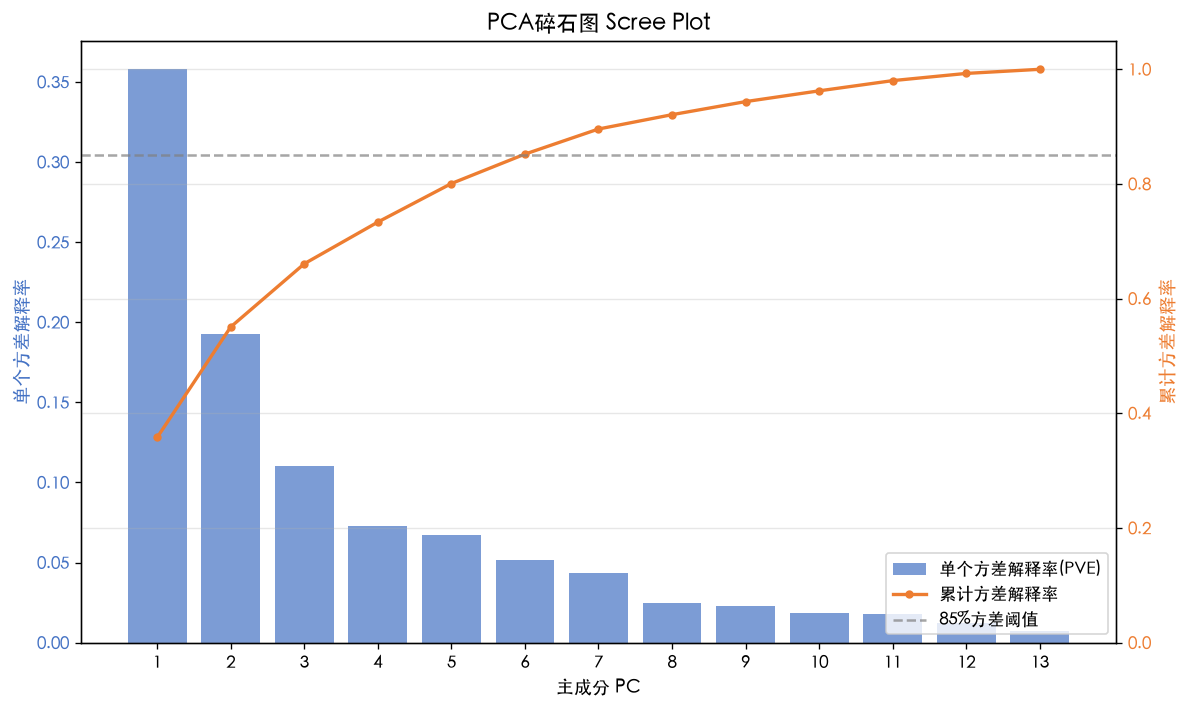

In [324]:
# df_n就是你上面构造的DataFrame
components = df_n["Principal Components"]
pve = df_n["PVE"]
cum_pve = df_n["cumlative PVE"]

fig, ax1 = plt.subplots(figsize=(10,6),dpi=120)

# 左Y轴：单个方差解释率 柱状图
ax1.bar(components, pve, color="#4472C4", alpha=0.7, label="单个方差解释率(PVE)")
ax1.set_xlabel("主成分 PC", fontsize=11)
ax1.set_ylabel("单个方差解释率", fontsize=11, color="#4472C4")
ax1.tick_params(axis="y", labelcolor="#4472C4")
ax1.set_xticks(components)

# 右Y轴：累计方差解释率
ax2 = ax1.twinx()
ax2.plot(components, cum_pve, color="#ED7D31", marker="o", linewidth=2, markersize=4, label="累计方差解释率")
ax2.set_ylabel("累计方差解释率", fontsize=11, color="#ED7D31")
ax2.tick_params(axis="y", labelcolor="#ED7D31")
ax2.set_ylim(0, 1.05)

# 画85%阈值虚线，标记你选择的标准
ax2.axhline(y=0.85, linestyle="--", color="gray", alpha=0.7, label="85%方差阈值")

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

plt.title("PCA碎石图 Scree Plot", fontsize=13)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 选取前6个进行降维

In [325]:
pca_final = PCA(n_components=6)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

In [326]:
print('各主成分方差解释率：',pca_final.explained_variance_ratio_)
print('累计方差解释：',np.sum(pca_final.explained_variance_ratio_))

各主成分方差解释率： [0.35792104 0.19270671 0.11019835 0.07272276 0.06721919 0.05131943]
累计方差解释： 0.8520874812704207


In [327]:
df_comp = pd.DataFrame(
    pca_final.components_,
    columns=wine.feature_names,
    index=[f"PC{i+1}" for i in range(pca_final.n_components)],
)
df_comp["explained_variance"] = pca_final.explained_variance_
df_comp["PVE"] = pca_final.explained_variance_ratio_
df_comp

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,explained_variance,PVE
PC1,0.144373,-0.233745,0.007065,-0.223590,0.151844,0.394392,0.429506,-0.291404,0.313349,-0.096410,0.296860,0.383162,0.289936,4.685973,0.357921
PC2,0.486947,0.222896,0.311578,-0.038970,0.296438,0.076266,-0.002534,0.020829,0.010904,0.524429,-0.297524,-0.170263,0.357511,2.522955,0.192707
PC3,-0.155700,0.063545,0.638470,0.640690,0.100182,0.144204,0.100029,0.184976,0.156364,-0.133094,0.119838,0.115864,-0.092675,1.442739,0.110198
PC4,-0.209884,0.501840,-0.198957,0.087322,0.267688,0.044929,0.050772,-0.458437,0.376593,-0.045112,-0.380352,0.067774,-0.278136,0.952101,0.072723
PC5,-0.195813,-0.361897,0.014924,0.029676,0.756403,-0.258067,-0.220459,-0.206201,-0.084233,-0.073047,0.180902,-0.220893,0.075950,0.880047,0.067219
PC6,-0.194831,-0.411300,-0.187255,0.040043,-0.036661,0.107595,0.021239,0.327390,0.622169,0.398921,-0.109799,-0.243857,-0.133776,0.671884,0.051319


## 前两个主成分可视化

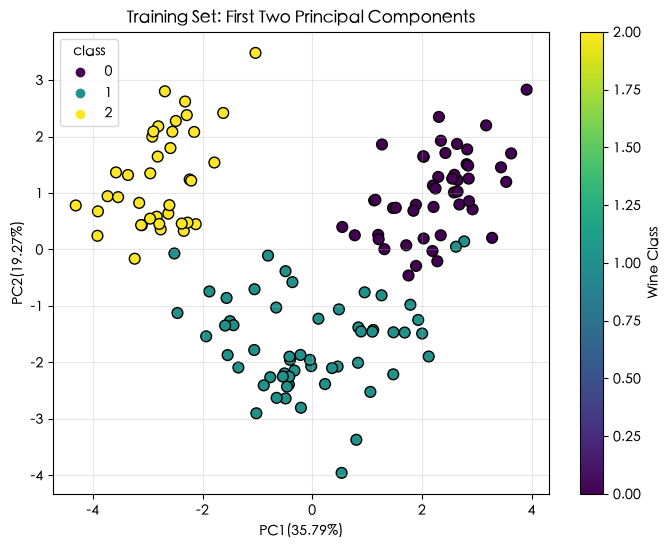

In [328]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_train_pca[:,0],X_train_pca[:,1],c=y_train,cmap='viridis',edgecolors='k',s=60)
plt.xlabel(f'PC1({pca_final.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2({pca_final.explained_variance_ratio_[1]:.2%})')
plt.title('Training Set: First Two Principal Components')
plt.legend(*scatter.legend_elements(),title='class')
plt.colorbar(scatter,label='Wine Class')
plt.grid(alpha=0.3)
plt.show()

## 逻辑回归模型训练与评估分类

### 在原始数据上训练

In [329]:
lr_raw = LogisticRegression()
lr_raw.fit(X_train_scaled,y_train)
y_pred_raw = lr_raw.predict(X_test_scaled)
accuracy_score(y_test,y_pred_raw)

0.9722222222222222

### 在降维后的数据上训练

In [330]:
lr = LogisticRegression()

In [331]:
lr.fit(X_train_pca,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [332]:
y_pred = lr.predict(X_test_pca)

In [333]:
print(classification_report(y_test,y_pred))
print('准确率：',accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36

准确率： 0.9722222222222222


## 逻辑回归分类

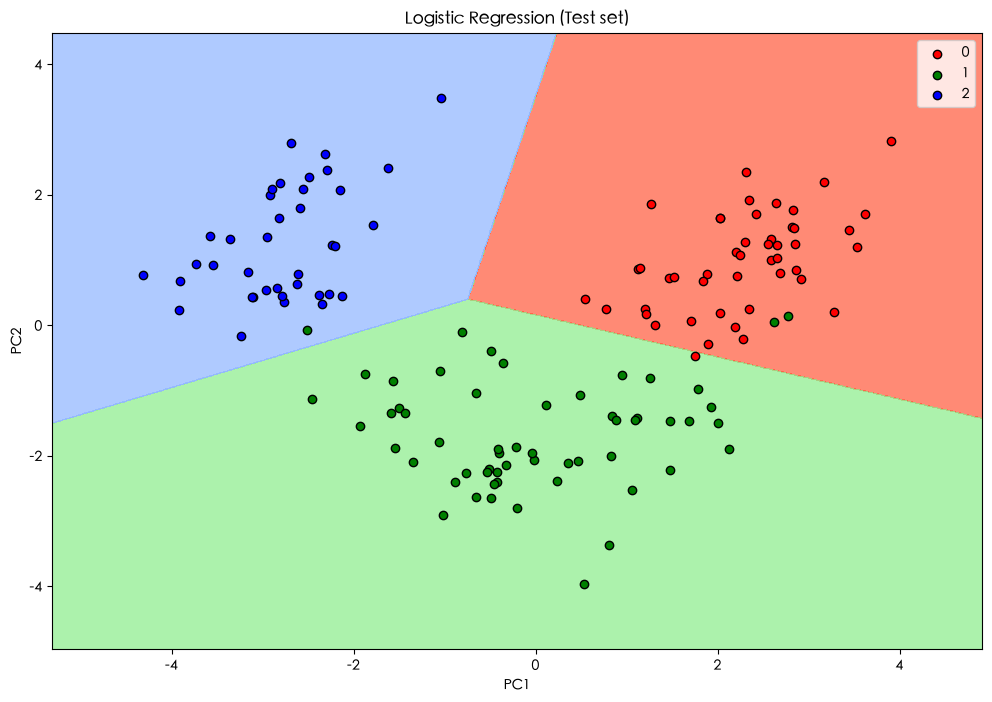

In [334]:
plt.figure(figsize=(12,8))
from matplotlib.colors import ListedColormap

# X_set,y_set = X_train_pca, y_train
X_set, y_set = X_train_pca[:, :2], y_train

# ✅专门为2维可视化重新训练逻辑回归（只用PC1、PC2）
lr_2d = LogisticRegression(max_iter=200)
lr_2d.fit(X_set, y_set)


X1, X2 = np.meshgrid(
    np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
    np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01)
)

grid_points = np.array([X1.ravel(), X2.ravel()]).T
Z = lr_2d.predict(grid_points)                             #改成逻辑回归对应的名称

Z = Z.astype(float)
Z = Z.reshape(X1.shape)


n_classes = len(np.unique(y_set))

bg_color_pool = ['#FF6347', '#90EE90', '#94b9ff', '#ffd700','#da70d6'] 
point_color_pool = ['red','green','blue','gold','magenta']

bg_cmap = ListedColormap(bg_color_pool[:n_classes])
point_colors = point_color_pool[:n_classes]


plt.contourf(X1, X2, Z,
             alpha = 0.75,
             cmap = ListedColormap(('#FF6347', '#90EE90', '#94b9ff')))

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0],
                X_set[y_set == j, 1],
                c = point_color_pool[i],
                label = j,edgecolors='k')

plt.title('Logistic Regression (Test set)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

# 交叉验证方法规避小测试集缺陷

In [335]:
from sklearn.model_selection import cross_val_score

lr_raw = LogisticRegression()
score_raw = cross_val_score(lr_raw,X_train_scaled,y_train,cv=5,scoring='accuracy')
print("原始特征5折cv均值：",score_raw.mean())

lr_pca = LogisticRegression()
score_pca = cross_val_score(lr,X_train_pca,y_train,cv=5,scoring='accuracy')
print("PCA‑6PC 5折cv均值：",score_pca.mean())

原始特征5折cv均值： 0.9859605911330049
PCA‑6PC 5折cv均值： 0.993103448275862


## 结果可视化

In [336]:
results = pd.DataFrame({'Method':['Original (13 features)', 'PCA (6 components)'],'Accuracy':[score_raw.mean(),score_pca.mean()]})

In [337]:
results

,Method,Accuracy
0,Original (13 features),0.985961
1,PCA (6 components),0.993103


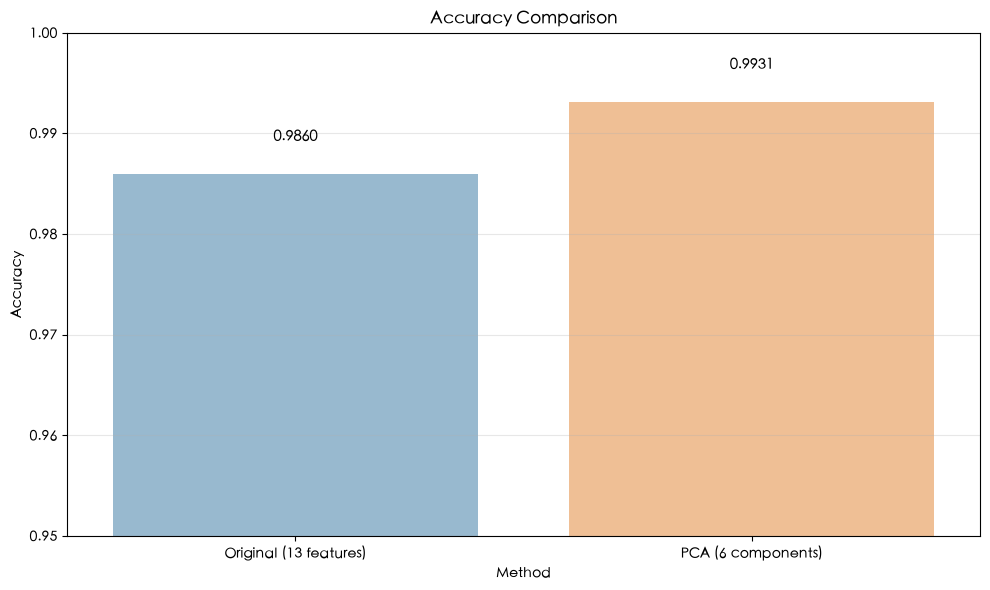

In [338]:
plt.figure(figsize=(10,6))
ax3 = sns.barplot(results,x='Method',y='Accuracy',hue='Method',legend=False,alpha=0.5)
plt.ylim(0.95,1)
plt.title('Accuracy Comparison')

for bar in ax3.patches:
    height = bar.get_height()
    ax3.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,    # 文字距离柱子顶部偏移，不要0.02！你的y轴范围很小，0.02会超出画布
        f'{height:.4f}',
        ha='center', va='bottom', fontsize=11
    )

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()